# Low- and high-metallicity power-law comparison

同じ質量範囲における低金属量・高金属量サンプルの power-law

$$v(t)=b\left(\frac{t}{4.6\,\mathrm{Gyr}}\right)^a$$

を比較する。保存済みの `result/<LABEL>/mcmc.nc` を読み込み、再推定は行わない。

In [1]:
from pathlib import Path

import arviz as az
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from rot_evol import (
    DAY_S, R_SUN_KM, IsochronePosterior, RotEvol,
    frame_ids_from_observation_log, selection_label, v_power,
)

## Settings

`MASS_RANGE` と `FEH_SPLIT` を変えると、比較対象の結果パスも自動的に変わる。
`PREDICT_P_ROT = True` では縦軸を $P_{\rm rot}/\sin i$、`False` では $v\sin i$ にする。

In [2]:
RESULT_ROOT = Path("result")
OBSERVATION_LOG = Path("observation_log.csv")
LOG_QUERY = None
MASS_RANGE = (1.1, 1.3)
# MASS_RANGE = (0.9, 1.1)
FEH_SPLIT = -0.1
PREDICT_P_ROT = False

LOW_FEH_RANGE = (None, FEH_SPLIT)
HIGH_FEH_RANGE = (FEH_SPLIT, None)

LOW_LABEL = f"importance_predict_age_Prot_{PREDICT_P_ROT}_" + selection_label(MASS_RANGE, LOW_FEH_RANGE)
HIGH_LABEL = f"importance_predict_age_Prot_{PREDICT_P_ROT}_" + selection_label(MASS_RANGE, HIGH_FEH_RANGE)
LOW_PATH = RESULT_ROOT / LOW_LABEL / "mcmc.nc"
HIGH_PATH = RESULT_ROOT / HIGH_LABEL / "mcmc.nc"

print("low [Fe/H]: ", LOW_PATH)
print("high [Fe/H]:", HIGH_PATH)

low [Fe/H]:  result/importance_predict_age_Prot_False_mass1.1-1.3_feh-0.1low/mcmc.nc
high [Fe/H]: result/importance_predict_age_Prot_False_mass1.1-1.3_feh-0.1up/mcmc.nc


In [3]:
def load_power_result(path):
    if not path.is_file():
        raise FileNotFoundError(f"Run the corresponding fit first: {path}")
    idata = az.from_netcdf(path)
    missing = {"a", "b"}.difference(idata.posterior.data_vars)
    if missing:
        raise ValueError(f"Missing power-law variables in {path}: {sorted(missing)}")
    if idata.attrs.get("model", "power") != "power":
        raise ValueError(f"Not a power-law result: {path}")
    return idata

idata_low = load_power_result(LOW_PATH)
idata_high = load_power_result(HIGH_PATH)
samples_low = idata_low.posterior.stack(sample=("chain", "draw"))
samples_high = idata_high.posterior.stack(sample=("chain", "draw"))

frame_ids = frame_ids_from_observation_log(
    OBSERVATION_LOG,
    query=LOG_QUERY,
    exclude_tags=("Trash",),
    keep_highest_sn_per_object=True,
    sn_column="Count (e-)",  
)

re_all = RotEvol.from_analysis_results(frame_ids, refresh_cache=False)
re_low = re_all.select(mass_range=MASS_RANGE, feh_range=LOW_FEH_RANGE)
re_high = re_all.select(mass_range=MASS_RANGE, feh_range=HIGH_FEH_RANGE)
iso_low = (
    IsochronePosterior.from_analysis_results(re_low.frame_id, refresh_cache=False)
    if PREDICT_P_ROT else None
)
iso_high = (
    IsochronePosterior.from_analysis_results(re_high.frame_id, refresh_cache=False)
    if PREDICT_P_ROT else None
)
n_low = re_low.N
n_high = re_high.N
print(f"low [Fe/H]:  {n_low} stars, {samples_low.sizes['sample']} posterior draws")
print(f"high [Fe/H]: {n_high} stars, {samples_high.sizes['sample']} posterior draws")

low [Fe/H]:  39 stars, 4000 posterior draws
high [Fe/H]: 43 stars, 4000 posterior draws


N_all=216

## Posterior summaries

In [4]:
summary = pd.concat(
    {
        "low [Fe/H]": az.summary(idata_low, var_names=["a", "b"], hdi_prob=0.94),
        "high [Fe/H]": az.summary(idata_high, var_names=["a", "b"], hdi_prob=0.94),
    },
    names=["sample", "parameter"],
)
summary

mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
sample      parameter                                                      
low [Fe/H]  a         -4.609  0.323  -5.000   -4.027      0.015    0.015   
            b          1.928  0.378   1.269    2.641      0.015    0.013   
high [Fe/H] a         -4.330  0.541  -4.999   -3.318      0.028    0.021   
            b          1.217  0.397   0.641    2.015      0.021    0.025   

                       ess_bulk  ess_tail  r_hat  
sample      parameter                             
low [Fe/H]  a             523.0     350.0   1.00  
            b             721.0     789.0   1.00  
high [Fe/H] a             404.0     446.0   1.02  
            b             497.0     380.0   1.01

## Joint posterior of $a$ and $b$

In [5]:
vlabel = "P_rot" if PREDICT_P_ROT else "v"

In [6]:
samples_low

<xarray.Dataset> Size: 2MB
Dimensions:               (sample: 4000, stars: 39)
Coordinates:
  * sample                (sample) object 32kB MultiIndex
  * stars                 (stars) int64 312B 0 1 2 3 4 5 6 ... 33 34 35 36 37 38
  * chain                 (sample) int64 32kB 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3
  * draw                  (sample) int64 32kB 0 1 2 3 4 ... 995 996 997 998 999
Data variables:
    a                     (sample) float64 32kB -4.979 -4.223 ... -4.673 -4.48
    b                     (sample) float64 32kB 1.874 1.732 1.73 ... 1.76 1.756
    cosi                  (stars, sample) float64 1MB 0.172 0.8269 ... 0.9301
    logb                  (sample) float64 32kB 0.2728 0.2385 ... 0.2454 0.2444
    loglognorm_age_sigma  (sample) float64 32kB -1.207 -0.943 ... -1.065 -1.156
    lognorm_age_mu        (sample) float64 32kB 9.489 9.476 ... 9.499 9.449
    lognorm_age_sigma     (sample) float64 32kB 0.06208 0.114 ... 0.06977
Attributes:
    created_at:                 2026-08-24T02:42:37.801623+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.16.1

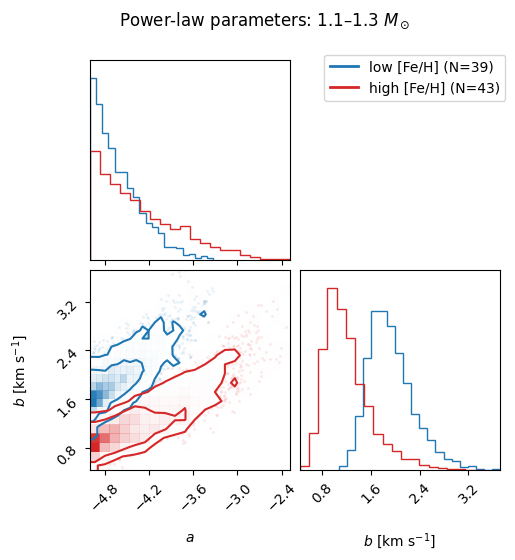

In [7]:
ab_low = np.column_stack([np.asarray(samples_low["a"]), np.asarray(samples_low["b"])])
ab_high = np.column_stack([np.asarray(samples_high["a"]), np.asarray(samples_high["b"])])
b_unit = r"day" if PREDICT_P_ROT else r"km s$^{-1}$"
labels = [r"$a$", fr"$b$ [{b_unit}]"]

figure = corner.corner(
    ab_low, labels=labels, color="C0", levels=(0.68, 0.94),
    hist_kwargs={"density": True,},
)
corner.corner(
    ab_high, labels=labels, color="C3", levels=(0.68, 0.94),
    fig=figure,
    hist_kwargs={"density": True,},
)
figure.legend(
    handles=[
        Line2D([], [], color="C0", lw=2, label=f"low [Fe/H] (N={n_low})"),
        Line2D([], [], color="C3", lw=2, label=f"high [Fe/H] (N={n_high})"),
    ],
    loc="upper right", bbox_to_anchor=(0.95, 0.95),
)
figure.suptitle(f"Power-law parameters: {MASS_RANGE[0]}–{MASS_RANGE[1]} $M_\odot$", y=1.02)
plt.savefig(f"../spec/figures/{vlabel}_compare_low_high_feh_power{MASS_RANGE[0]}-{MASS_RANGE[1]}M_corner.png", dpi=300, bbox_inches="tight")

## Power-law comparison

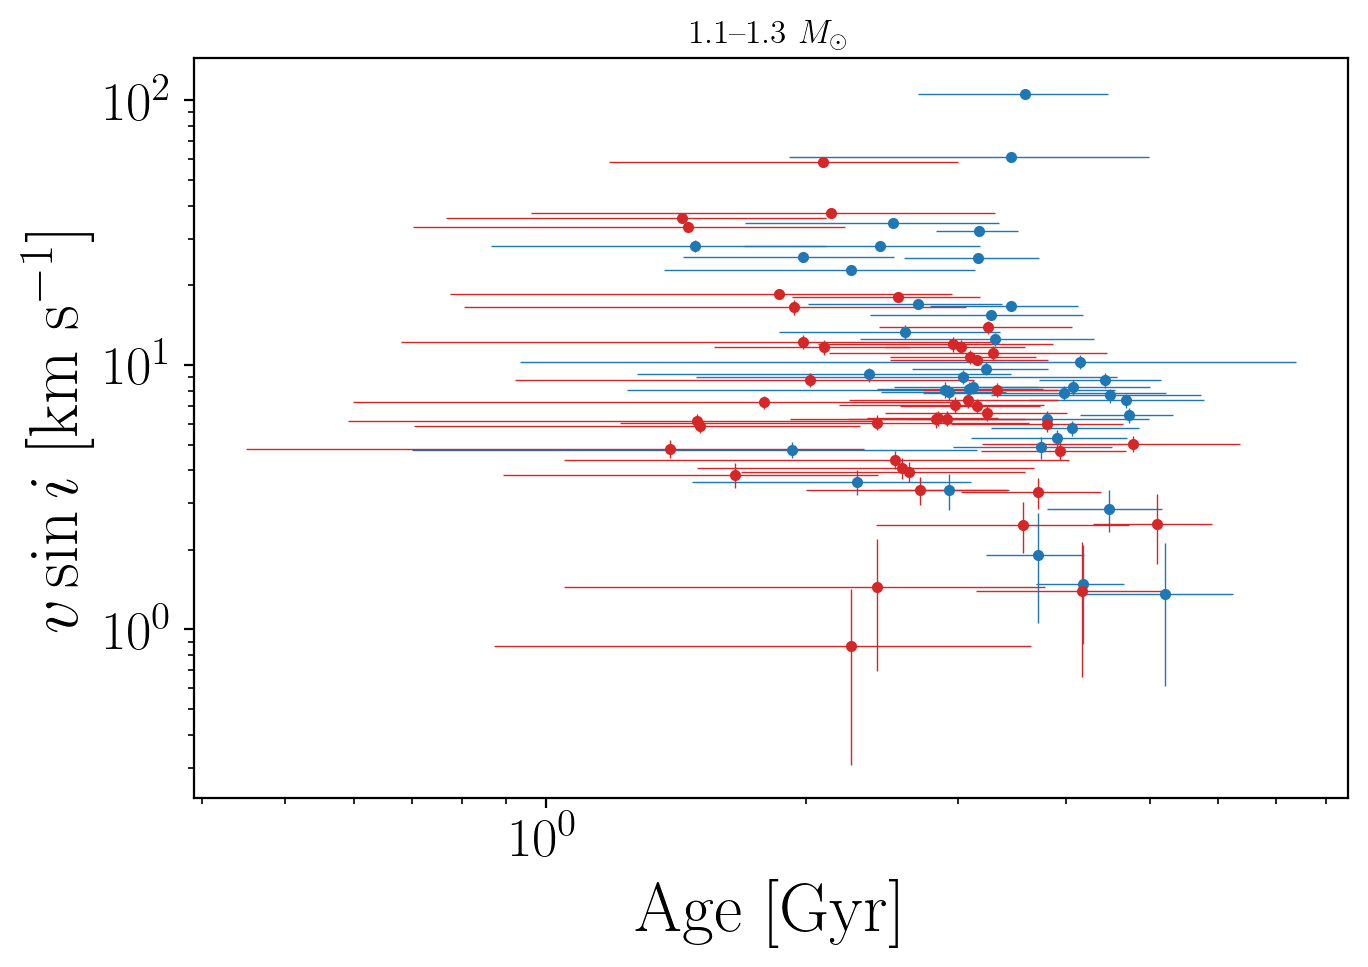

In [8]:
def observed_rotation(re, isochrone_posterior):
    if not PREDICT_P_ROT:
        return re.vsini, re.vsini_err, r"$v\sin i$"
    if not np.array_equal(re.frame_id, isochrone_posterior.frame_id):
        raise ValueError("RotEvol and IsochronePosterior frame_id/order must match")
    radius = np.median(isochrone_posterior.radius, axis=1)
    radius_err = np.std(isochrone_posterior.radius, axis=1)
    period_over_sini = 2.0 * np.pi * radius * R_SUN_KM / (re.vsini * DAY_S)
    period_over_sini_err = period_over_sini * np.sqrt(
        (radius_err / radius) ** 2 + (re.vsini_err / re.vsini) ** 2
    )
    return period_over_sini, period_over_sini_err, r"$P_{\rm rot}/\sin i$"


plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 25,
        "axes.titlesize": 12,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "text.usetex": True,
        "font.family": "serif",
        "figure.dpi": 200,
    }
)


age_grid = np.geomspace(0.1, 13.8, 400)
fig, ax = plt.subplots(figsize=(7, 5))

for samples, re, isochrone_posterior, color, label in (
    (samples_low, re_low, iso_low, "C0", "low [Fe/H]"),
    (samples_high, re_high, iso_high, "C3", "high [Fe/H]"),
):
    observed, observed_err, observed_label = observed_rotation(re, isochrone_posterior)
    ax.errorbar(
        re.age, observed, xerr=re.age_err, yerr=observed_err,
        fmt="o", ms=3, 
        # mfc="none", 
        # mec=color, 
        # ecolor=color, 
        color=color,
        elinewidth=0.5,
        # alpha=0.6, 
        label=f"{label} {observed_label}",
    )
    curves = np.asarray(v_power(
        age_grid[None, :],
        np.asarray(samples["a"])[:, None],
        np.asarray(samples["b"])[:, None],
    ))
    lower, median, upper = np.quantile(curves, [0.16, 0.5, 0.84], axis=0)
    # ax.fill_between(age_grid, lower, upper, color=color, alpha=0.20)
    # ax.plot(age_grid, median, color=color, lw=2, label=f"{label} power law")

# ax.axvline(4.6, color="0.4", ls=":", label="solar age")
ax.set(
    xscale="log", yscale="log",
    # ylim=(0.1, 60),
    # xlim=(0.1, 6),
    xlabel="Age [Gyr]",
    ylabel=(r"$P_{\rm rot}$ [day]" if PREDICT_P_ROT else r"$v\sin i$ [km s$^{-1}$]"),
)
# ax.legend()
ax.set_title(f"{MASS_RANGE[0]}–{MASS_RANGE[1]} $M_\odot$")
fig.tight_layout()

# plt.savefig(f"../spec/figures/{vlabel}_compare_low_high_feh_power{MASS_RANGE[0]}-{MASS_RANGE[1]}.png", dpi=300, bbox_inches="tight")

In [9]:
len(samples_low["cosi"].values[0])

4000

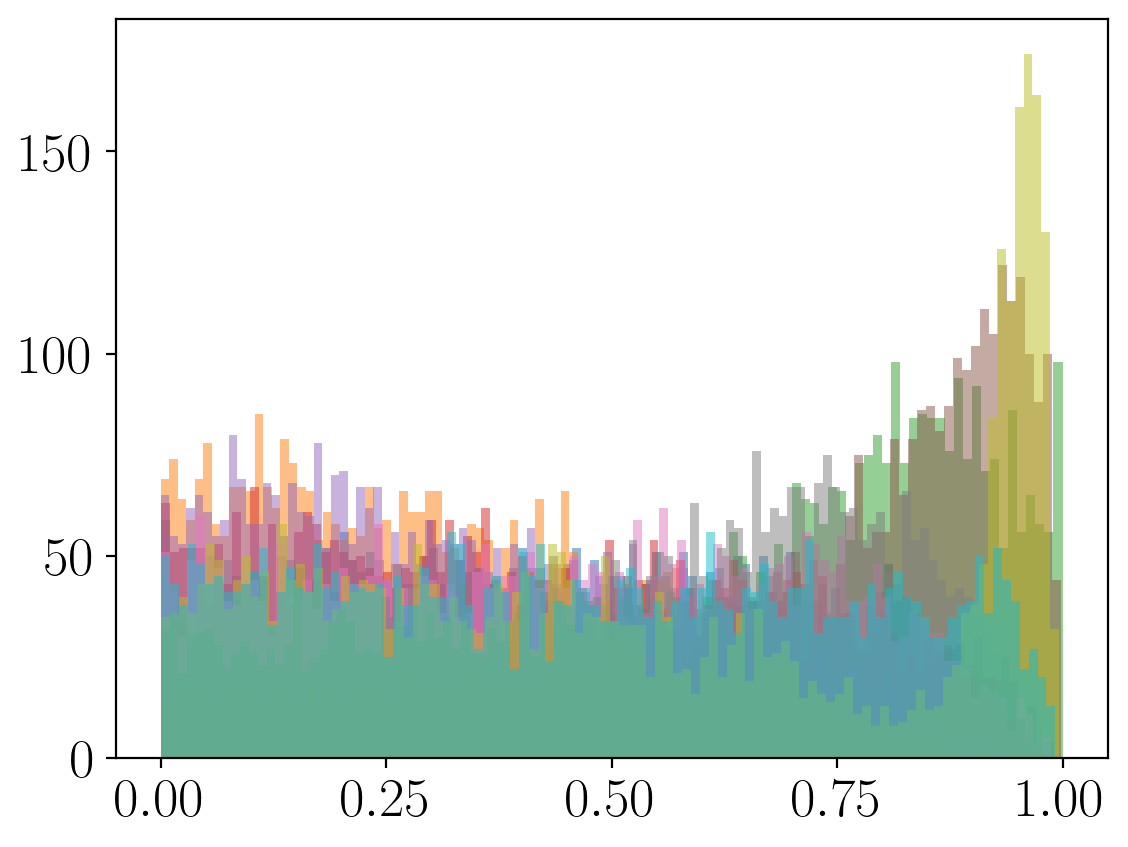

In [10]:
for i in range(10):    
    plt.hist(samples_low["cosi"].values[i], alpha=0.5, bins=100)
